# Algo 3: Unified Inference with Disentangled Rejection
## CICIoT2023 | Full Training Checkpoint | Recalibrate q | Analytic $L_\varphi$ (R/2)
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from pennylane import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

In [2]:
from scripts.cache import (
    ForwardCache,
    cached_class_conditional_calibrate,
    cached_nonconformity_scores,
    cached_per_class_far,
    cached_predict_labels,
    cached_qsnet_infer,
    cached_qsnet_infer_per_class,
    conformal_alpha_sweep_from_scores,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.conformal import threshold_from_scores
from scripts.constants import (
    DEFAULT_ALPHA,
    DEFAULT_BATCH_SIZE,
    DEFAULT_CF,
    DEFAULT_NOISE_RATE,
    ZERO_DAY,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
    stratified_head,
    to_angles,
)
from scripts.logging import write_history_log
from scripts.theory import analytic_lipschitz_bound, clopper_pearson_ci
from scripts.utils import get_torch_device, to_np_y

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Config

In [4]:
NOTEBOOK_NAME = "final-ciciot2023-algo3-cached (maqt)"
DAY23_NOTEBOOK = "final-ciciot2023-maqt-train"

dataset = "CICIoT2023"
target_col = "label_multiclass"
data_path = f"data/FROZEN/{dataset}"
frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

SEED = 42

## Load Team C's FROZEN Features

In [5]:
handoff = json.loads(Path(frozen_feat_path).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"Team C selector: {handoff['frozen_subsets'][dataset]['selector']}")
print(f"k={len(FEATURE_COLS)} features: {FEATURE_COLS}")

Team C selector: MI
k=10 features: ['duration', 'n_pkts_total', 'n_bytes_total', 'rate', 'pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'iat', 'protocol', 'conn_state']


## Load Team A's FROZEN Dataset

In [6]:
# load all data
X_train_full, y_train_full, class_names, df_train = load_split(
    data_path,
    "train",
    target_col,
    categories=None,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,
)
X_cal_full, y_cal_full, _, df_cal = load_split(
    data_path,
    "calibration",
    target_col,
    categories=class_names,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,
)
X_test_full, y_test_full, _, df_test = load_split(
    data_path,
    "test",
    target_col,
    categories=class_names,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,
)
X_zero_full, y_zero_full, _, df_zero = load_split(
    data_path,
    "zeroday",
    target_col,
    categories=None,
    csv=True,
    selected_cols=FEATURE_COLS,
    return_df=True,  # categories must be None for zeroday set
)

# check shape
print(
    f"train   : {X_train_full.shape, y_train_full.shape}\n\
cal     : {X_cal_full.shape, y_cal_full.shape}\n\
test    : {X_test_full.shape, y_test_full.shape}\n\
zero    : {X_zero_full.shape, y_zero_full.shape}\n\
classes : {class_names}\n"
)

df_train.head(3)

train   : ((151049, 10), (151049,))
cal     : ((18883, 10), (18883,))
test    : ((18883, 10), (18883,))
zero    : ((10984, 10), (10984,))
classes : ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']



,duration,n_pkts_total,n_bytes_total,rate,pkt_size_min,pkt_size_max,pkt_size_mean,iat,protocol,conn_state,label_multiclass
0,0.114311,0.627152,0.005499,-0.306870,0.000000,0.050420,0.000000,0.855064,0.000000,-1.368171,DDoS-RSTFINFlood
1,11.888079,59.170326,2.426720,0.744359,2.613771,22.605136,11.713125,-314.863555,-1.322219,-1.217438,BenignTraffic
2,0.000000,-0.250922,-3.264916,0.257804,-3.259715,-2.850162,-3.252384,0.020018,-1.000000,0.000000,DDoS-ICMP_Flood


## EDA (Before Subset)

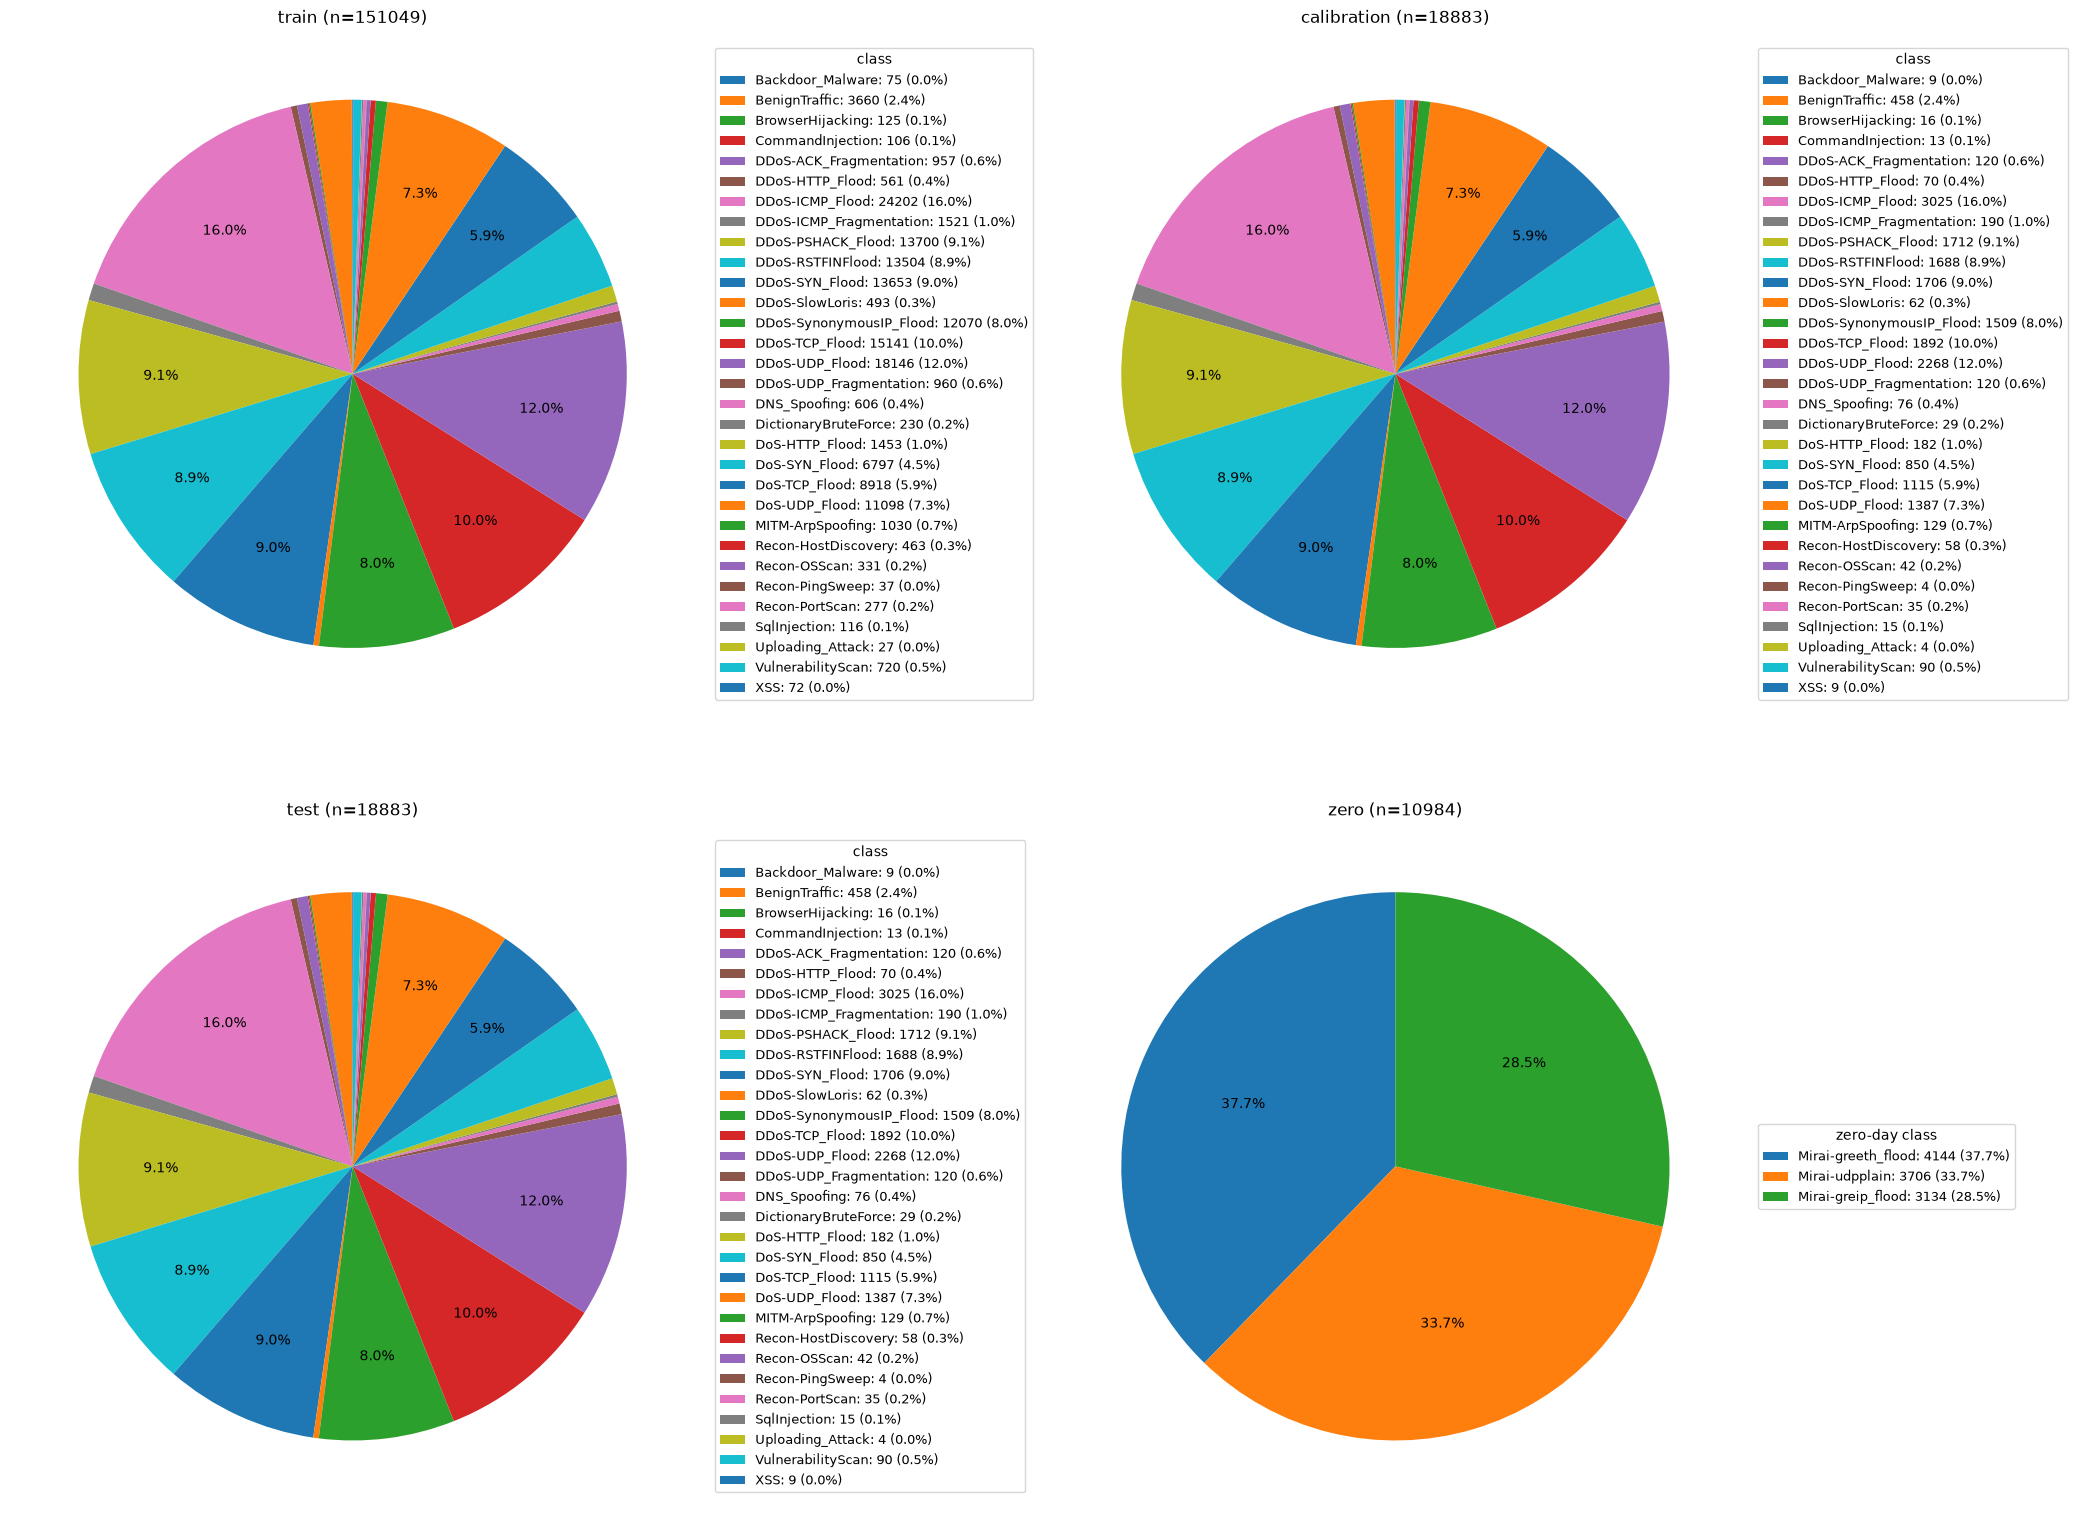

In [7]:
splits = {
    "train": y_train_full,
    "calibration": y_cal_full,
    "test": y_test_full,
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.ravel()

# train, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

vc = df_zero[target_col].value_counts()
ax.pie(
    vc.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
    startangle=90,
)
ax.legend(
    [f"{lab}: {n} ({100 * n / vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

# remove extra chart if exists
for ax in axes[len(splits) + 1 :]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Data Subset (Optional)

In [8]:
SUBSET = True  # set to False for the full known splits
MORE_SUBSET = False  # set to True for smaller cal/test/zero to make a quick pass
PER_CLASS_CAP = 1000

In [9]:
if SUBSET is True:
    X_train, y_train = capped_sample(
        X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED
    )
else:
    X_train, y_train = X_train_full, y_train_full

if MORE_SUBSET is True:
    X_cal, y_cal = stratified_head(X_cal_full, y_cal_full, 400, seed=SEED)
    X_test, y_test = stratified_head(X_test_full, y_test_full, 400, seed=SEED)
    X_zero, y_zero, idx_zero = stratified_head(
        X_zero_full, y_zero_full, 40, seed=SEED, return_index=True
    )
else:
    X_cal, y_cal = X_cal_full, y_cal_full
    X_test, y_test = X_test_full, y_test_full
    X_zero, y_zero = X_zero_full, y_zero_full
    idx_zero = np.arange(len(X_zero))

df_zero_subset = df_zero.iloc[idx_zero].reset_index(drop=True)

# check shape
print(
    f"train : {X_train.shape, y_train.shape}\n\
cal   : {X_cal.shape, y_cal.shape}\n\
test  : {X_test.shape, y_test.shape}\n\
zero  : {X_zero.shape, y_zero.shape}"
)

train : ((20156, 10), (20156,))
cal   : ((18883, 10), (18883,))
test  : ((18883, 10), (18883,))
zero  : ((10984, 10), (10984,))


## EDA (After Subset)

number of classes: 31


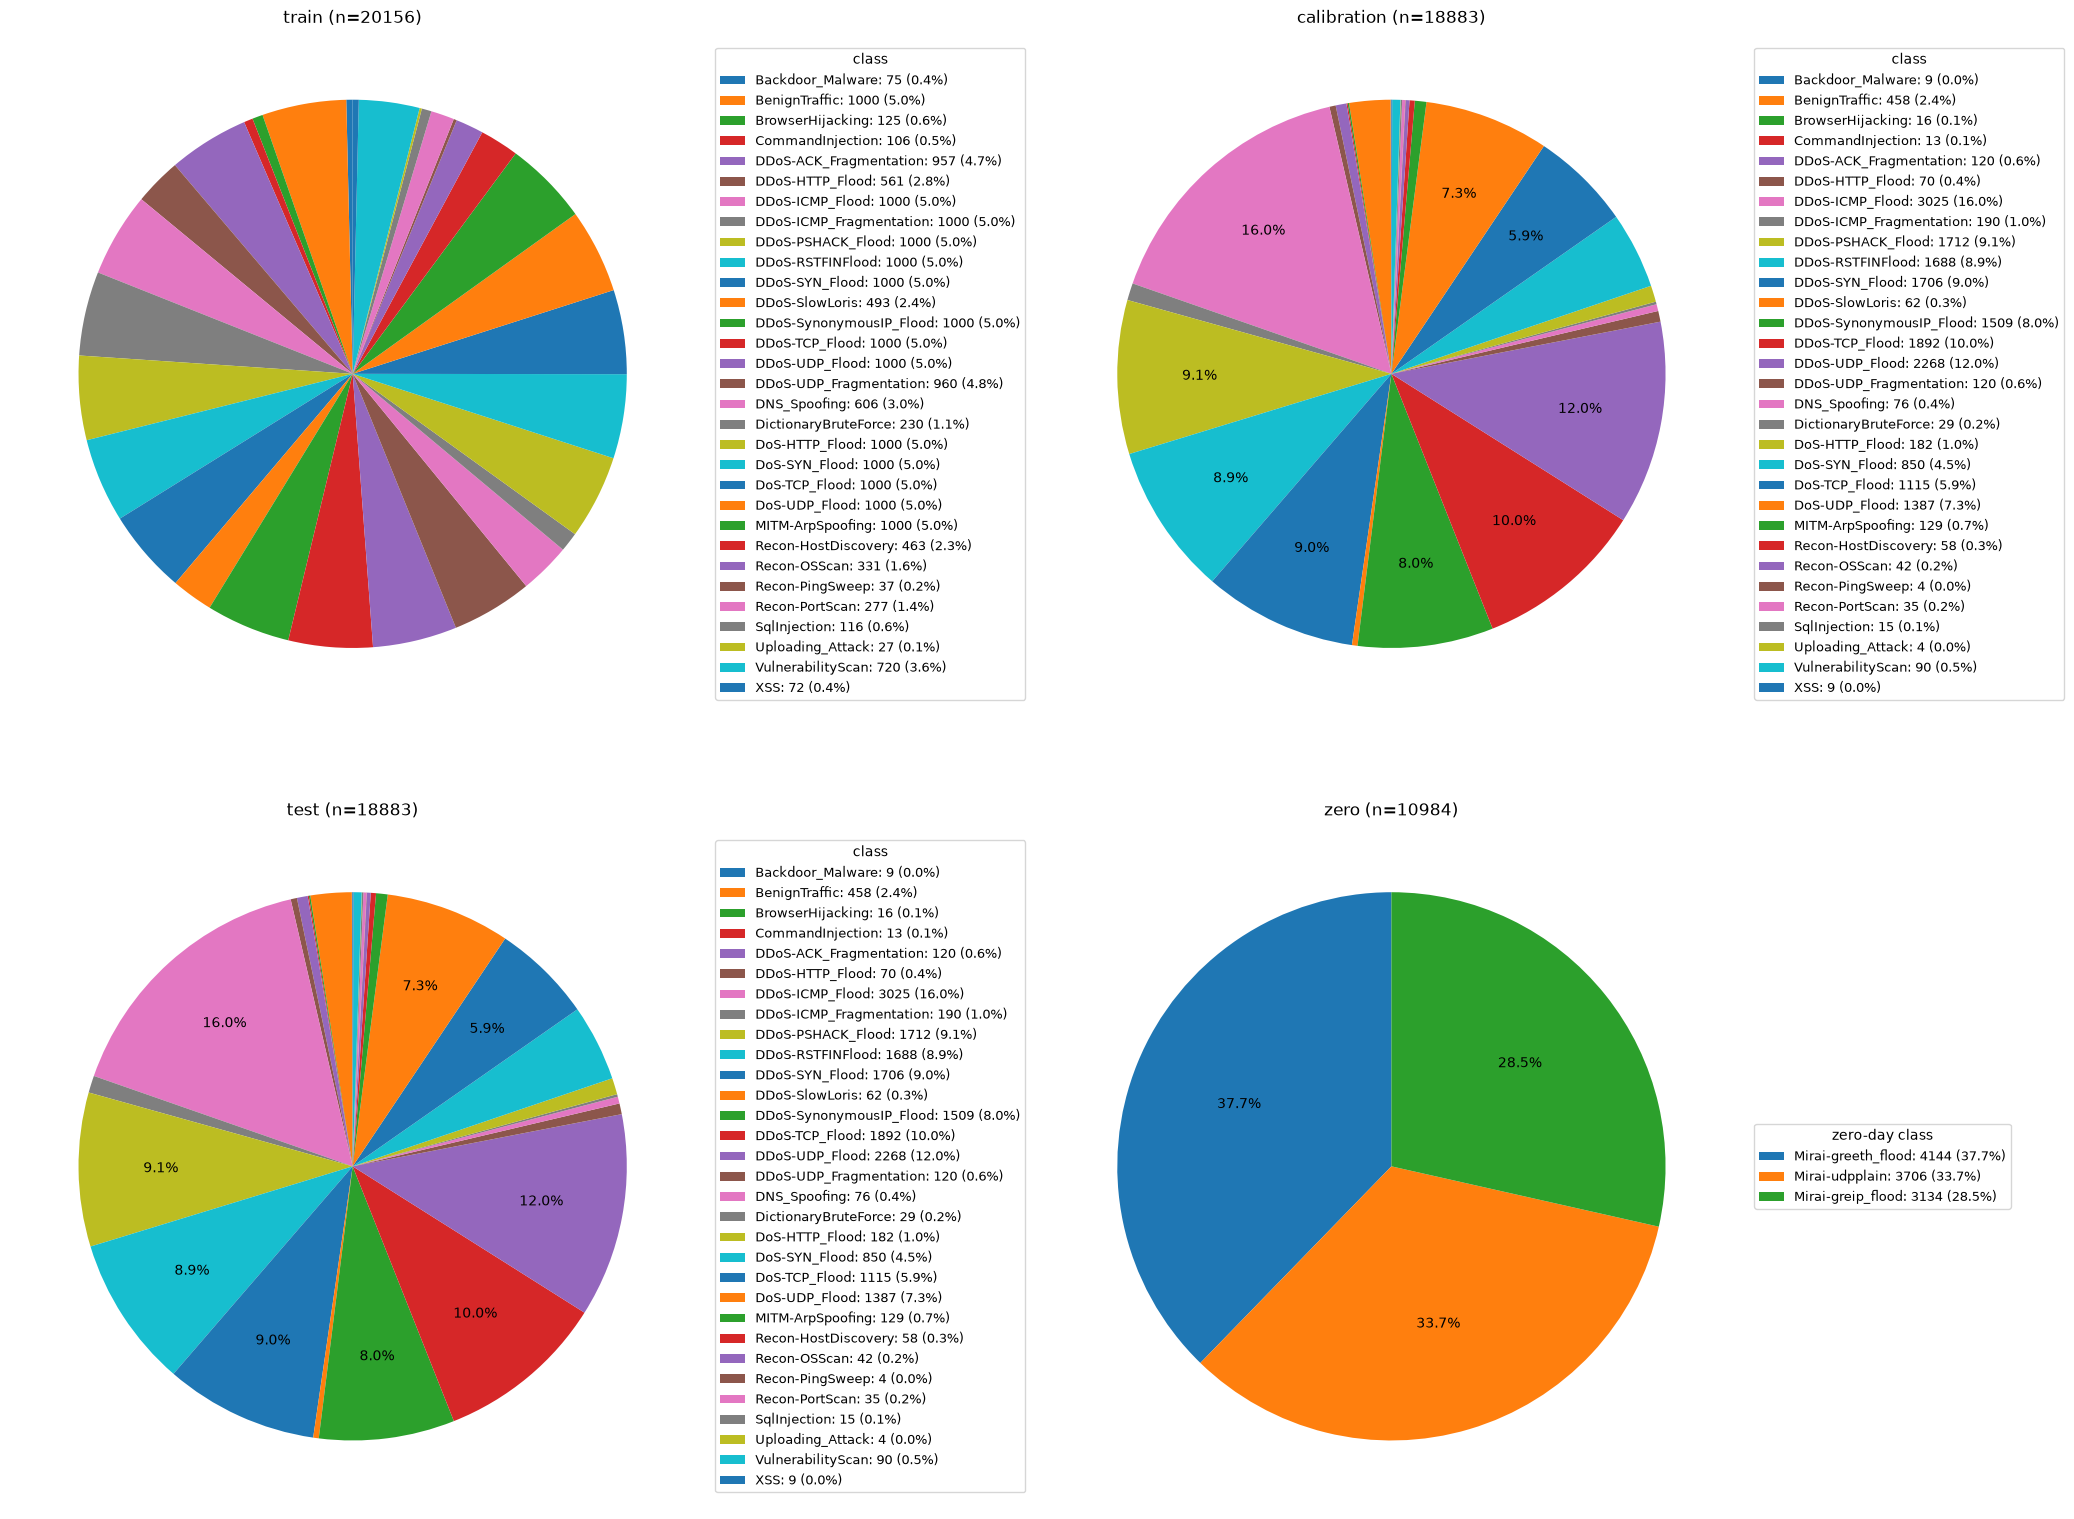

In [10]:
num_classes = len(class_names)
print(f"number of classes: {num_classes}")

splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.ravel()

for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

ax = axes[len(splits)]
vc = df_zero_subset[target_col].value_counts()
ax.pie(
    vc.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
    startangle=90,
)
ax.legend(
    [f"{lab}: {n} ({100 * n / vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero_subset)})")

for ax in axes[len(splits) + 1 :]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Load Day-23 FROZEN Checkpoint

Reuse $\theta^\star$, prototypes, and the train-fitted scaler / PCA / angle bounds from Day-23.


In [11]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY23_NOTEBOOK}-checkpoint.pt",
    Path("final_notebooks/final_artifacts") / f"{DAY23_NOTEBOOK}-checkpoint.pt",
]

batch_size = DEFAULT_BATCH_SIZE
seed = SEED

In [12]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
history = {}
head = None

if not (LOAD_CHECKPOINT and ckpt_path is not None):
    raise FileNotFoundError(
        f"Day-23 checkpoint not found under {CHECKPOINT_CANDIDATES}. "
        f"Publish it from {DAY23_NOTEBOOK}_(final).ipynb first."
    )

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

theta_star = ckpt["theta"]
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)

prototypes = {int(k): v for k, v in ckpt["prototypes"].items()}
class_names = list(ckpt.get("class_names", class_names))
num_classes = int(ckpt.get("num_classes", len(class_names)))
num_qubits = int(ckpt["num_qubits"])
num_layers = int(ckpt.get("num_layers", 2))
noise_rate = float(ckpt.get("noise_rate", DEFAULT_NOISE_RATE))

scaler = ckpt["scaler"]
pca = ckpt.get("pca")
USE_PCA = bool(ckpt.get("use_pca", pca is not None))
x_min = np.asarray(ckpt["angle_x_min"])
x_max = np.asarray(ckpt["angle_x_max"])
angle_max = float(ckpt.get("angle_max", np.pi))
k95 = int(ckpt.get("k95", num_qubits))

if "head_state_dict" in ckpt:
    head = torch.nn.Linear(num_qubits, num_classes)
    head.load_state_dict(ckpt["head_state_dict"])

print(f"loaded checkpoint: {ckpt_path}")
print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")
print(
    f"num_qubits={num_qubits} | num_layers={num_layers} | USE_PCA={USE_PCA} | k95={k95}"
)
print(f"feature_cols: {len(ckpt.get('feature_cols', FEATURE_COLS))}")

loaded checkpoint: final_notebooks/final_artifacts/final-ciciot2023-maqt-train-checkpoint.pt
theta shape: (3, 6, 3) | prototypes: 31
num_qubits=6 | num_layers=3 | USE_PCA=True | k95=6
feature_cols: 10


## Mapping Features $\rightarrow$ [0, $\pi$]


angles cal: (18883, 6), | angles test: (18883, 6), | angles zero: (10984, 6) | USE_PCA=True


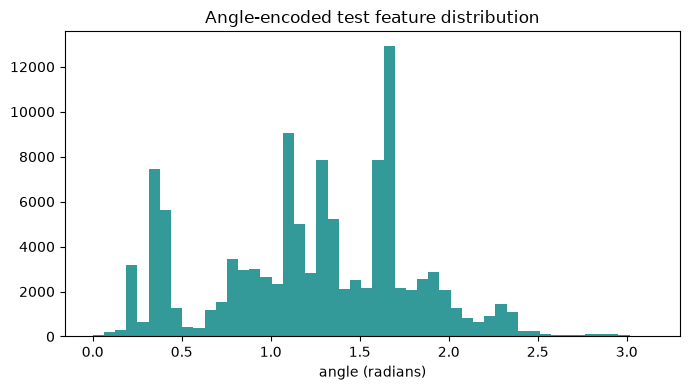

In [13]:
# raw -> scale -> optional pca -> [0, pi] using Day-23 train bounds
pca_for_angles = pca if USE_PCA else None
X_cal_angles = to_angles(
    X_cal, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)
X_test_angles = to_angles(
    X_test, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)
X_zero_angles = to_angles(
    X_zero, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)
X_train_angles = to_angles(
    X_train, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)

print(
    f"angles cal: {X_cal_angles.shape}, | angles test: {X_test_angles.shape}, | angles zero: {X_zero_angles.shape} | USE_PCA={USE_PCA}"
)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.hist(X_test_angles.flatten(), bins=50, color="teal", alpha=0.8)
ax1.set_xlabel("angle (radians)")
ax1.set_title("Angle-encoded test feature distribution")
plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$$
x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)
$$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [14]:
print(
    f"num_qubits={num_qubits} (from Day-23) | num_layers={num_layers} | noise_rate={noise_rate}"
)

num_qubits=6 (from Day-23) | num_layers=3 | noise_rate=0.01


In [15]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(
    num_qubits
)  # or qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(
    dev, num_qubits, num_layers, noise_rate=noise_rate
)

# move model tensors to device
theta_star = theta_star.to(device)
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)
prototypes = {int(k): v.to(device) for k, v in prototypes.items()}
if head is not None:
    head = head.to(device)

print(f"device={device}")

device=cuda


## Forward Cache

- Run the encoder once per split
- Store $(z, \rho)$ on CPU
- Downstream conformal / Algo-3 reuse these without re-running the circuit

In [16]:
cache = ForwardCache(store_device="cpu")

CACHE_SPLITS = {
    "train": X_train_angles,
    "cal": X_cal_angles,
    "test": X_test_angles,
    "zeroday": X_zero_angles,
}

t0 = time.time()
for key, X_ang in CACHE_SPLITS.items():
    entry = cache.compute(
        key,
        X_ang,
        theta_star,
        forward_circuit,
        device=device,
        batch_size=batch_size,
        p=noise_rate,
    )
    print(
        f"[{key:8s}] n={entry['n']:,}  rho={tuple(entry['rho'].shape)}  z={tuple(entry['z'].shape)}"
    )
print(f"forward cache built in {time.time() - t0:.1f}s")

# optional disk persist (reload skips recompute if you load below instead)
cache_dir = Path("caches") / dataset
cache_dir.mkdir(parents=True, exist_ok=True)
cache_path = cache_dir / f"{NOTEBOOK_NAME}-forward_cache.pt"
save_dict = {
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path) if ckpt_path else None,
    "day23_notebook": DAY23_NOTEBOOK,
    "num_qubits": num_qubits,
    "num_layers": num_layers,
    "noise_rate": noise_rate,
    "class_names": list(class_names),
    "seed": SEED,
}
for key in CACHE_SPLITS:
    entry = cache.get(key)
    save_dict[f"{key}_z"] = entry["z"]
    save_dict[f"{key}_rho"] = entry["rho"]
    save_dict[f"{key}_n"] = entry["n"]
torch.save(save_dict, cache_path)
print(f"saved cache: {cache_path.resolve()} ({cache_path.stat().st_size / 1e6:.1f} MB)")

[train   ] n=20,156  rho=(20156, 64, 64)  z=(20156, 6)
[cal     ] n=18,883  rho=(18883, 64, 64)  z=(18883, 6)
[test    ] n=18,883  rho=(18883, 64, 64)  z=(18883, 6)
[zeroday ] n=10,984  rho=(10984, 64, 64)  z=(10984, 6)
forward cache built in 314.4s
saved cache: /home/lawun330/Desktop/quantum-sentinel/caches/CICIoT2023/final-ciciot2023-algo3-cached (maqt)-forward_cache.pt (4517.5 MB)


## Lipschitz Bound $L_\varphi$ (Analytic R/2)

**Lemma 1**: For angle encoding with data reupload, $L_\varphi = R/2$ with $R=$ `num_layers`.

In [17]:
L_phi = analytic_lipschitz_bound(num_layers, reupload=True)
lphi_path = None
print(f"using analytic L_phi=R/2={L_phi:.4f} (num_layers={num_layers})")

using analytic L_phi=R/2=1.5000 (num_layers=3)


## Conformal Zero-Day Threshold Calibration (q)

- Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.
- Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

Recalibrate $q$ on Day-23 angle-encoded $X_{\mathrm{cal}}$.

In [18]:
alpha = DEFAULT_ALPHA
alpha

0.05

In [19]:
cal_scores = cached_nonconformity_scores(
    cache.get("cal"),
    prototypes,
    device=device,
    batch_size=batch_size,
)
q, scores_sorted = threshold_from_scores(cal_scores, alpha=alpha)
q_source = "threshold_from_scores(cal_scores) on Day-23 checkpoint + ForwardCache"
print(f"calibrated q={q:.6f} (alpha={alpha}, n_cal={len(cal_scores)})")

calibrated q=0.226019 (alpha=0.05, n_cal=18883)


### Note
α-sweep and per-class FAR run **after** Global infer, reusing `cal_scores` + `scores_test_g` (see the diagnostics cell below Global vs Mondrian).

In [20]:
Cf = DEFAULT_CF
zero_day = ZERO_DAY
p = noise_rate
label_ids = list(range(num_classes))
y_test_np = to_np_y(y_test).astype(int)

print(f"p       : {p}")
print(f"L_phi   : {L_phi:.4f}")
print(f"C_f     : {Cf}")
print(f"q       : {q:.6f}")

p       : 0.01
L_phi   : 1.5000
C_f     : 1.0
q       : 0.226019


## Global vs Mondrian (Class-conditional) Conformal

Run **once** on the ForwardCache, then reuse for RQ1 / test reports.

- **Global**: one threshold $q$ (already calibrated).
- **Mondrian**: per-class thresholds $q_c$ (reuses `cal_scores`).

In [21]:
# Mondrian calibration (per-class q_c); reuse cal_scores from global calibrate
q_by_class, calib_meta = cached_class_conditional_calibrate(
    cache.get("cal"),
    y_cal,
    prototypes,
    alpha=alpha,
    device=device,
    batch_size=batch_size,
    fallback="global",
    scores=cal_scores,
)

print("Per-class (Mondrian) thresholds:")
for c in sorted(prototypes.keys()):
    m = calib_meta[c]
    print(f"  {class_names[c]:15s} n={m['n']:5d}  q={m['q']:.4f}  status={m['status']}")
print(
    f"  global (marginal) q = {calib_meta['_global']['q']:.4f}  |  notebook global q = {q:.4f}"
)

Per-class (Mondrian) thresholds:
  Backdoor_Malware n=    9  q=0.2260  status=insufficient for alpha=0.05 -- used GLOBAL threshold (Calibration set too small for alpha=0.05: n=9, but Proposition 3 requires n >= (1/alpha) - 1 = 19.00. Abstaining rather than using the largest calibration score -- collect more calibration data or increase alpha.)
  BenignTraffic   n=  458  q=0.3931  status=ok
  BrowserHijacking n=   16  q=0.2260  status=insufficient for alpha=0.05 -- used GLOBAL threshold (Calibration set too small for alpha=0.05: n=16, but Proposition 3 requires n >= (1/alpha) - 1 = 19.00. Abstaining rather than using the largest calibration score -- collect more calibration data or increase alpha.)
  CommandInjection n=   13  q=0.2260  status=insufficient for alpha=0.05 -- used GLOBAL threshold (Calibration set too small for alpha=0.05: n=13, but Proposition 3 requires n >= (1/alpha) - 1 = 19.00. Abstaining rather than using the largest calibration score -- collect more calibration data

In [22]:
print("=" * 60)
print("ZERO-DAY DETECTION: GLOBAL vs MONDRIAN")
print("=" * 60)

# --- Global ---
labels_zday_g, radii_zday_g, scores_zday_g, _ = cached_qsnet_infer(
    cache.get("zeroday"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
labels_test_g, radii_test_g, scores_test_g, f_maps_test_g = cached_qsnet_infer(
    cache.get("test"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)

tp_g, n_g = int(np.sum(labels_zday_g == ZERO_DAY)), len(labels_zday_g)
fp_g, m_g = int(np.sum(labels_test_g == ZERO_DAY)), len(labels_test_g)
TPR_g, FPR_g = tp_g / n_g, fp_g / m_g
tpr_g_lo, tpr_g_hi = clopper_pearson_ci(tp_g, n_g)
fpr_g_lo, fpr_g_hi = clopper_pearson_ci(fp_g, m_g)

accepted_g = labels_test_g != ZERO_DAY
class_acc_g = (
    float(np.mean(labels_test_g[accepted_g] == y_test_np[accepted_g]))
    if accepted_g.any()
    else float("nan")
)

# --- Mondrian ---
labels_zday_pc, radii_zday_pc, scores_zday_pc, _ = cached_qsnet_infer_per_class(
    cache.get("zeroday"),
    prototypes,
    q_by_class,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
labels_test_pc, radii_test_pc, scores_test_pc, _ = cached_qsnet_infer_per_class(
    cache.get("test"),
    prototypes,
    q_by_class,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)

tp_pc, n_pc = int(np.sum(labels_zday_pc == ZERO_DAY)), len(labels_zday_pc)
fp_pc, m_pc = int(np.sum(labels_test_pc == ZERO_DAY)), len(labels_test_pc)
TPR_pc, FPR_pc = tp_pc / n_pc, fp_pc / m_pc
tpr_pc_lo, tpr_pc_hi = clopper_pearson_ci(tp_pc, n_pc)
fpr_pc_lo, fpr_pc_hi = clopper_pearson_ci(fp_pc, m_pc)

accepted_pc = labels_test_pc != ZERO_DAY
class_acc_pc = (
    float(np.mean(labels_test_pc[accepted_pc] == y_test_np[accepted_pc]))
    if accepted_pc.any()
    else float("nan")
)

df_global_vs_mondrian = pd.DataFrame(
    [
        {
            "method": "Global",
            "TPR": TPR_g,
            "TPR_lo": tpr_g_lo,
            "TPR_hi": tpr_g_hi,
            "FPR": FPR_g,
            "FPR_lo": fpr_g_lo,
            "FPR_hi": fpr_g_hi,
            "class_acc_accepted": class_acc_g,
        },
        {
            "method": "Mondrian",
            "TPR": TPR_pc,
            "TPR_lo": tpr_pc_lo,
            "TPR_hi": tpr_pc_hi,
            "FPR": FPR_pc,
            "FPR_lo": fpr_pc_lo,
            "FPR_hi": fpr_pc_hi,
            "class_acc_accepted": class_acc_pc,
        },
    ]
)

print(
    f"[global]   TPR={TPR_g:.4f} (CI [{tpr_g_lo:.4f},{tpr_g_hi:.4f}])  "
    f"FPR={FPR_g:.4f} (CI [{fpr_g_lo:.4f},{fpr_g_hi:.4f}])  "
    f"known-acc(accepted)={class_acc_g:.4f}"
)
print(
    f"[mondrian] TPR={TPR_pc:.4f} (CI [{tpr_pc_lo:.4f},{tpr_pc_hi:.4f}])  "
    f"FPR={FPR_pc:.4f} (CI [{fpr_pc_lo:.4f},{fpr_pc_hi:.4f}])  "
    f"known-acc(accepted)={class_acc_pc:.4f}"
)

# reuse global branch for downstream test reports / hist / RQ1 (no second infer)
y_pred, radii, novelty_scores, f_maps = (
    labels_test_g,
    radii_test_g,
    scores_test_g,
    f_maps_test_g,
)
y_zero_pred, radii_zero, scores_zero = labels_zday_g, radii_zday_g, scores_zday_g
detection_rate = float(TPR_g)

df_global_vs_mondrian

ZERO-DAY DETECTION: GLOBAL vs MONDRIAN
[global]   TPR=0.0105 (CI [0.0087,0.0126])  FPR=0.0530 (CI [0.0498,0.0562])  known-acc(accepted)=0.7034
[mondrian] TPR=0.0442 (CI [0.0405,0.0483])  FPR=0.1327 (CI [0.1279,0.1376])  known-acc(accepted)=0.7608


,method,TPR,TPR_lo,TPR_hi,FPR,FPR_lo,FPR_hi,class_acc_accepted
0,Global,0.010470,0.008651,0.012554,0.052958,0.049806,0.056248,0.703405
1,Mondrian,0.044246,0.040476,0.048260,0.132712,0.127903,0.137634,0.760762


In [23]:
# diagnostics from already-computed scores (no extra fidelity / nonconformity pass)
# cal_scores    -> from global calibrate
# scores_test_g -> from Global infer above (same for Mondrian)

alphas = (0.01, 0.05, 0.1, 0.2)
alpha_rows = conformal_alpha_sweep_from_scores(cal_scores, scores_test_g, alphas=alphas)
df_alpha = pd.DataFrame(alpha_rows)
print("alpha sweep (from cal_scores + scores_test_g):")
print(df_alpha.to_string(index=False))
print()

q_global_map = {c: float(q) for c in prototypes}
far_global = cached_per_class_far(
    cache.get("test"),
    y_test,
    prototypes,
    q_global_map,
    device=device,
    batch_size=batch_size,
    scores=scores_test_g,
)
far_mondrian = cached_per_class_far(
    cache.get("test"),
    y_test,
    prototypes,
    q_by_class,
    device=device,
    batch_size=batch_size,
    scores=scores_test_g,
)

df_far = pd.DataFrame(
    [
        {
            "class": class_names[r["class"]],
            "n": r["n"],
            "FAR_global": r["empirical_far"],
            "FAR_mondrian": r2["empirical_far"],
            "q_global": r["q"],
            "q_mondrian": r2["q"],
        }
        for r, r2 in zip(far_global, far_mondrian)
    ]
)
df_far["abs_dev_global"] = (df_far["FAR_global"] - alpha).abs()
df_far["abs_dev_mondrian"] = (df_far["FAR_mondrian"] - alpha).abs()
print(
    f"FAR spread  global={df_far['FAR_global'].max() - df_far['FAR_global'].min():.4f}  "
    f"mondrian={df_far['FAR_mondrian'].max() - df_far['FAR_mondrian'].min():.4f}"
)
df_far

alpha sweep (from cal_scores + scores_test_g):
 alpha        q  empirical_false_alarm_rate  min_calibration_size  n_cal
  0.01 0.361367                    0.011968                  99.0  18883
  0.05 0.226019                    0.052958                  19.0  18883
  0.10 0.150187                    0.105439                   9.0  18883
  0.20 0.053629                    0.226553                   4.0  18883

FAR spread  global=1.0000  mondrian=1.0000


,class,n,FAR_global,FAR_mondrian,q_global,q_mondrian,abs_dev_global,abs_dev_mondrian
0,Backdoor_Malware,9,1.000000,1.000000,0.226019,0.226019,0.950000,0.950000
1,BenignTraffic,458,0.962882,0.098253,0.226019,0.393125,0.912882,0.048253
2,BrowserHijacking,16,1.000000,1.000000,0.226019,0.226019,0.950000,0.950000
3,CommandInjection,13,1.000000,1.000000,0.226019,0.226019,0.950000,0.950000
4,DDoS-ACK_Fragmentation,120,0.016667,0.016667,0.226019,0.217584,0.033333,0.033333
5,DDoS-HTTP_Flood,70,0.071429,0.057143,0.226019,0.246570,0.021429,0.007143
6,DDoS-ICMP_Flood,3025,0.000331,0.067769,0.226019,0.031142,0.049669,0.017769
7,DDoS-ICMP_Fragmentation,190,0.005263,0.010526,0.226019,0.193718,0.044737,0.039474
8,DDoS-PSHACK_Flood,1712,0.011098,0.088201,0.226019,0.192075,0.038902,0.038201
9,DDoS-RSTFINFlood,1688,0.015995,0.095379,0.226019,0.188476,0.034005,0.045379


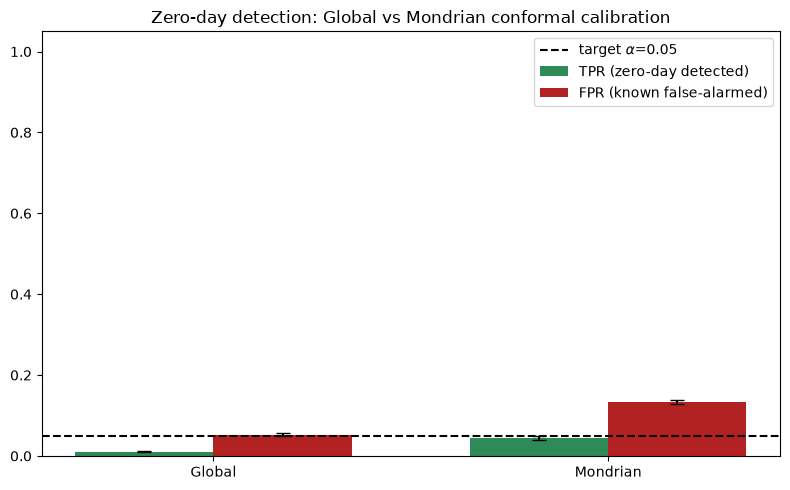

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_global_vs_mondrian))
width = 0.35
tpr_err = [
    df_global_vs_mondrian["TPR"] - df_global_vs_mondrian["TPR_lo"],
    df_global_vs_mondrian["TPR_hi"] - df_global_vs_mondrian["TPR"],
]
fpr_err = [
    df_global_vs_mondrian["FPR"] - df_global_vs_mondrian["FPR_lo"],
    df_global_vs_mondrian["FPR_hi"] - df_global_vs_mondrian["FPR"],
]
ax.bar(
    x - width / 2,
    df_global_vs_mondrian["TPR"],
    width,
    yerr=tpr_err,
    capsize=5,
    label="TPR (zero-day detected)",
    color="seagreen",
)
ax.bar(
    x + width / 2,
    df_global_vs_mondrian["FPR"],
    width,
    yerr=fpr_err,
    capsize=5,
    label="FPR (known false-alarmed)",
    color="firebrick",
)
ax.axhline(alpha, color="black", linestyle="--", label=rf"target $\alpha$={alpha}")
ax.set_xticks(x)
ax.set_xticklabels(df_global_vs_mondrian["method"])
ax.set_ylim(0, 1.05)
ax.set_title("Zero-day detection: Global vs Mondrian conformal calibration")
ax.legend()
plt.tight_layout()
plt.show()

## Score Histograms: Global vs Mondrian q

Same nonconformity scores $s(x)=1-F_{\max}$

- Global uses one $q$
- Mondrian uses per-class $q_c$.

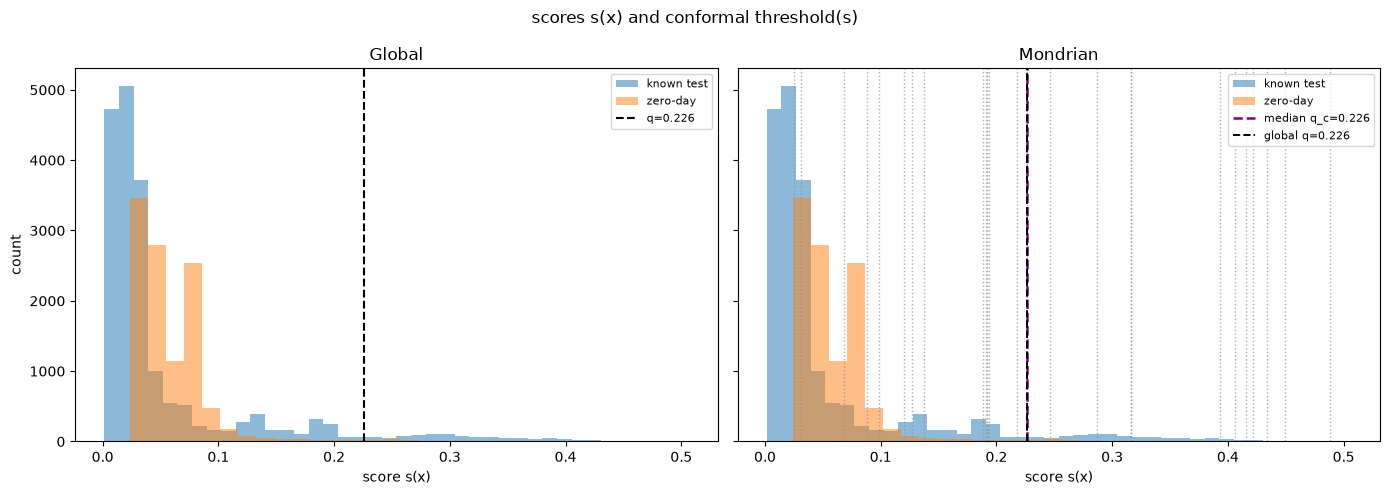

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Global ---
axes[0].hist(scores_test_g, bins=40, alpha=0.5, label="known test")
axes[0].hist(scores_zday_g, bins=30, alpha=0.5, label="zero-day")
axes[0].axvline(q, color="k", linestyle="--", label=f"q={q:.3f}")
axes[0].set_title("Global")
axes[0].set_xlabel("score s(x)")
axes[0].set_ylabel("count")
axes[0].legend(fontsize=8, loc="upper right")

# --- Mondrian ---
axes[1].hist(scores_test_pc, bins=40, alpha=0.5, label="known test")
axes[1].hist(scores_zday_pc, bins=30, alpha=0.5, label="zero-day")

q_vals = np.array(sorted(q_by_class.values()), dtype=float)
q_unique = np.unique(np.round(q_vals, 6))  # collapse duplicates

# faint lines, no legend spam
for q_c in q_unique:
    axes[1].axvline(q_c, color="0.55", linestyle=":", linewidth=1.0, alpha=0.7)

axes[1].axvline(
    np.median(q_vals),
    color="purple",
    linestyle="--",
    linewidth=1.8,
    label=f"median q_c={np.median(q_vals):.3f}",
)
axes[1].axvline(q, color="k", linestyle="--", linewidth=1.4, label=f"global q={q:.3f}")

axes[1].set_title("Mondrian")
axes[1].set_xlabel("score s(x)")
axes[1].legend(fontsize=8, loc="upper right")

fig.suptitle("scores s(x) and conformal threshold(s)")
plt.tight_layout()
plt.show()

## RQ1 Detection Numbers

Flip `CHOSEN_STRATEGY` to promote Global or Mondrian as the primary RQ1 numbers.

In [26]:
# which conformal strategy is primary for RQ1 / downstream Global-style reports
CHOSEN_STRATEGY = "global"  # "global" | "mondrian"

strategies = {
    "global": {
        "chosen_as_strategy": CHOSEN_STRATEGY == "global",
        "q": float(q),
        "TPR_zeroday": float(TPR_g),
        "FPR_known": float(FPR_g),
        "class_acc_known": float(class_acc_g),
        "TPR_lo": float(tpr_g_lo),
        "TPR_hi": float(tpr_g_hi),
        "FPR_lo": float(fpr_g_lo),
        "FPR_hi": float(fpr_g_hi),
    },
    "mondrian": {
        "chosen_as_strategy": CHOSEN_STRATEGY == "mondrian",
        "q_by_class": {int(k): float(v) for k, v in q_by_class.items()},
        "TPR_zeroday": float(TPR_pc),
        "FPR_known": float(FPR_pc),
        "class_acc_known": float(class_acc_pc),
        "TPR_lo": float(tpr_pc_lo),
        "TPR_hi": float(tpr_pc_hi),
        "FPR_lo": float(fpr_pc_lo),
        "FPR_hi": float(fpr_pc_hi),
    },
}

# primary RQ1 aliases (charts / prints use these)
_primary = strategies[CHOSEN_STRATEGY]
TPR_zeroday = float(_primary["TPR_zeroday"])
FPR_known = float(_primary["FPR_known"])
class_acc_known = float(_primary["class_acc_known"])

# side-by-side convenience names (always both strategies)
TPR_zeroday_global = float(strategies["global"]["TPR_zeroday"])
FPR_known_global = float(strategies["global"]["FPR_known"])
class_acc_known_global = float(strategies["global"]["class_acc_known"])
TPR_zeroday_mondrian = float(strategies["mondrian"]["TPR_zeroday"])
FPR_known_mondrian = float(strategies["mondrian"]["FPR_known"])
class_acc_known_mondrian = float(strategies["mondrian"]["class_acc_known"])

print(f"target alpha={alpha}")
print(f"chosen_strategy={CHOSEN_STRATEGY}")
print()
for name, m in strategies.items():
    tag = " [CHOSEN]" if m["chosen_as_strategy"] else ""
    print(f"=== {name}{tag} ===")
    print(f"  TPR_zeroday:      {m['TPR_zeroday']:.4f}")
    print(f"  FPR_known:        {m['FPR_known']:.4f}")
    print(f"  class_acc_known:  {m['class_acc_known']:.4f}")
print()
print(f"n_test={len(y_test_np)} | n_zeroday={len(X_zero_angles)}")

target alpha=0.05
chosen_strategy=global

=== global [CHOSEN] ===
  TPR_zeroday:      0.0105
  FPR_known:        0.0530
  class_acc_known:  0.7034
=== mondrian ===
  TPR_zeroday:      0.0442
  FPR_known:        0.1327
  class_acc_known:  0.7608

n_test=18883 | n_zeroday=10984


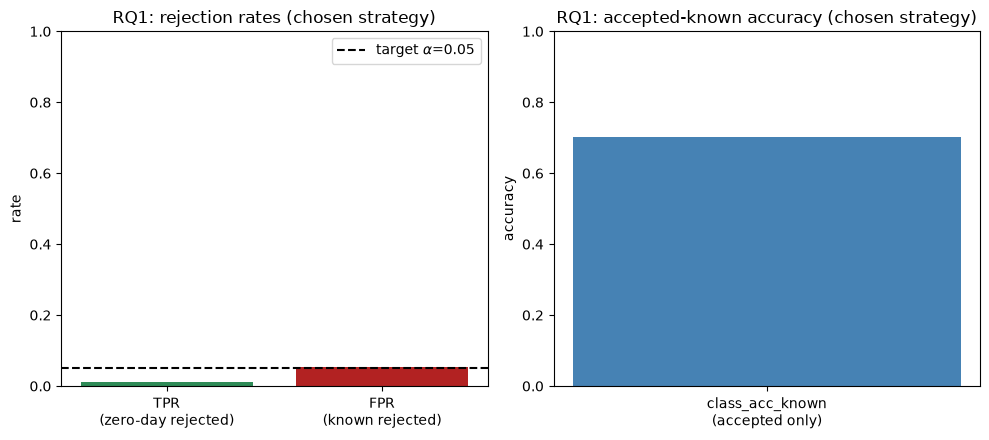

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar(
    ["TPR\n(zero-day rejected)", "FPR\n(known rejected)"],
    [TPR_zeroday, FPR_known],
    color=["seagreen", "firebrick"],
)
axes[0].axhline(alpha, color="black", linestyle="--", label=rf"target $\alpha$={alpha}")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("rate")
axes[0].set_title("RQ1: rejection rates (chosen strategy)")
axes[0].legend()

axes[1].bar(["class_acc_known\n(accepted only)"], [class_acc_known], color="steelblue")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("accuracy")
axes[1].set_title("RQ1: accepted-known accuracy (chosen strategy)")

plt.tight_layout()
plt.show()

## Evaluation on Training Samples Themselves (Non-Rejected By $q$)

In [28]:
y_pred_train, radii_train, novelty_scores_train, f_maps_train = cached_qsnet_infer(
    cache.get("train"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
y_train_np = to_np_y(y_train).astype(int)
label_ids = list(range(num_classes))

[train] mean certified radius (accepted): 0.0161
[train] reject rate (known): 0.2424 | acc (accepted): 0.6491

[train] classification report (accepted only):
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00         0
          BenignTraffic       0.48      1.00      0.65        33
       BrowserHijacking       0.00      0.00      0.00         1
       CommandInjection       0.00      0.00      0.00         2
 DDoS-ACK_Fragmentation       0.97      0.77      0.86       923
        DDoS-HTTP_Flood       0.47      0.65      0.54       509
        DDoS-ICMP_Flood       0.55      0.96      0.70      1000
DDoS-ICMP_Fragmentation       0.80      0.95      0.87       972
      DDoS-PSHACK_Flood       0.78      0.85      0.81       989
       DDoS-RSTFINFlood       1.00      0.78      0.87       982
         DDoS-SYN_Flood       0.37      0.46      0.41       998
         DDoS-SlowLoris       0.66      0.51      0.57       

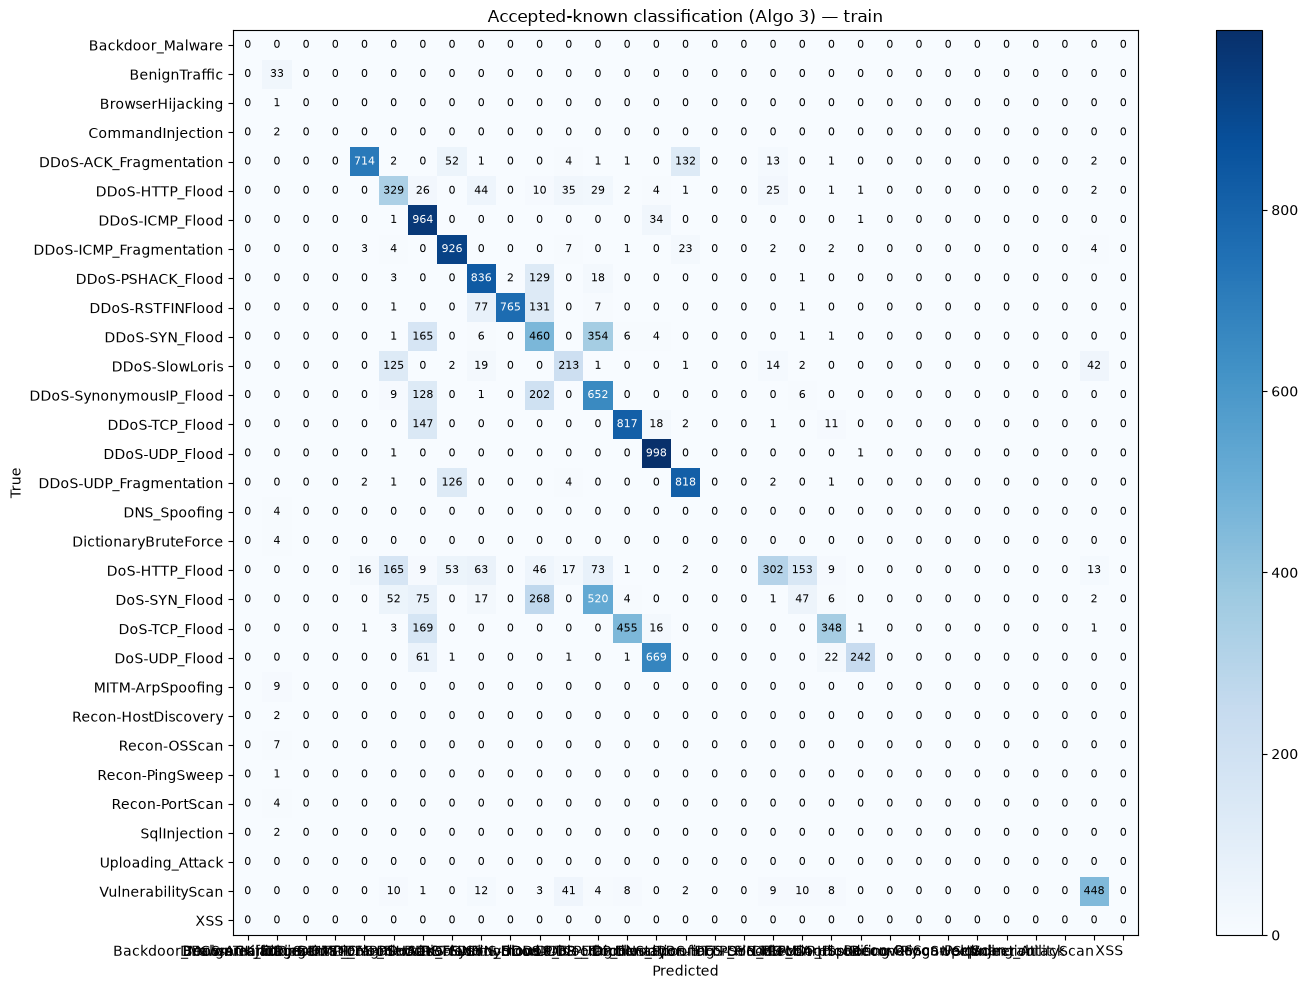

In [29]:
known_mask_train = y_pred_train != ZERO_DAY
train_eval_rej_rate = float(1.0 - known_mask_train.mean())
train_eval_acc = (
    float(np.mean(y_pred_train[known_mask_train] == y_train_np[known_mask_train]))
    if known_mask_train.any()
    else 0.0
)
train_eval_macro_f1 = float(
    f1_score(
        y_train_np[known_mask_train],
        y_pred_train[known_mask_train],
        average="macro",
        labels=label_ids,
        zero_division=0,
    )
)
train_eval_radius_mean = (
    float(radii_train[known_mask_train].mean())
    if known_mask_train.any()
    else float("nan")
)

print(f"[train] mean certified radius (accepted): {train_eval_radius_mean:.4f}")
print(
    f"[train] reject rate (known): {train_eval_rej_rate:.4f} | acc (accepted): {train_eval_acc:.4f}"
)

if known_mask_train.any():
    print("\n[train] classification report (accepted only):")
    print(
        classification_report(
            y_train_np[known_mask_train],
            y_pred_train[known_mask_train],
            labels=label_ids,
            target_names=class_names,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_train_np[known_mask_train],
        y_pred_train[known_mask_train],
        labels=label_ids,
    )

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3) — train",
    )
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Test Samples (Non-Rejected By $q$)

[test] mean certified radius (accepted): 0.0143
[test] reject rate (known): 0.0530 | acc (accepted): 0.7034

[test] classification report (accepted only):
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00         0
          BenignTraffic       0.73      0.94      0.82        17
       BrowserHijacking       0.00      0.00      0.00         0
       CommandInjection       0.00      0.00      0.00         0
 DDoS-ACK_Fragmentation       0.97      0.79      0.87       118
        DDoS-HTTP_Flood       0.23      0.62      0.33        65
        DDoS-ICMP_Flood       0.74      0.96      0.84      3024
DDoS-ICMP_Fragmentation       0.86      0.97      0.91       189
      DDoS-PSHACK_Flood       0.90      0.84      0.87      1693
       DDoS-RSTFINFlood       0.99      0.78      0.88      1661
         DDoS-SYN_Flood       0.44      0.45      0.44      1699
         DDoS-SlowLoris       0.57      0.44      0.49        55

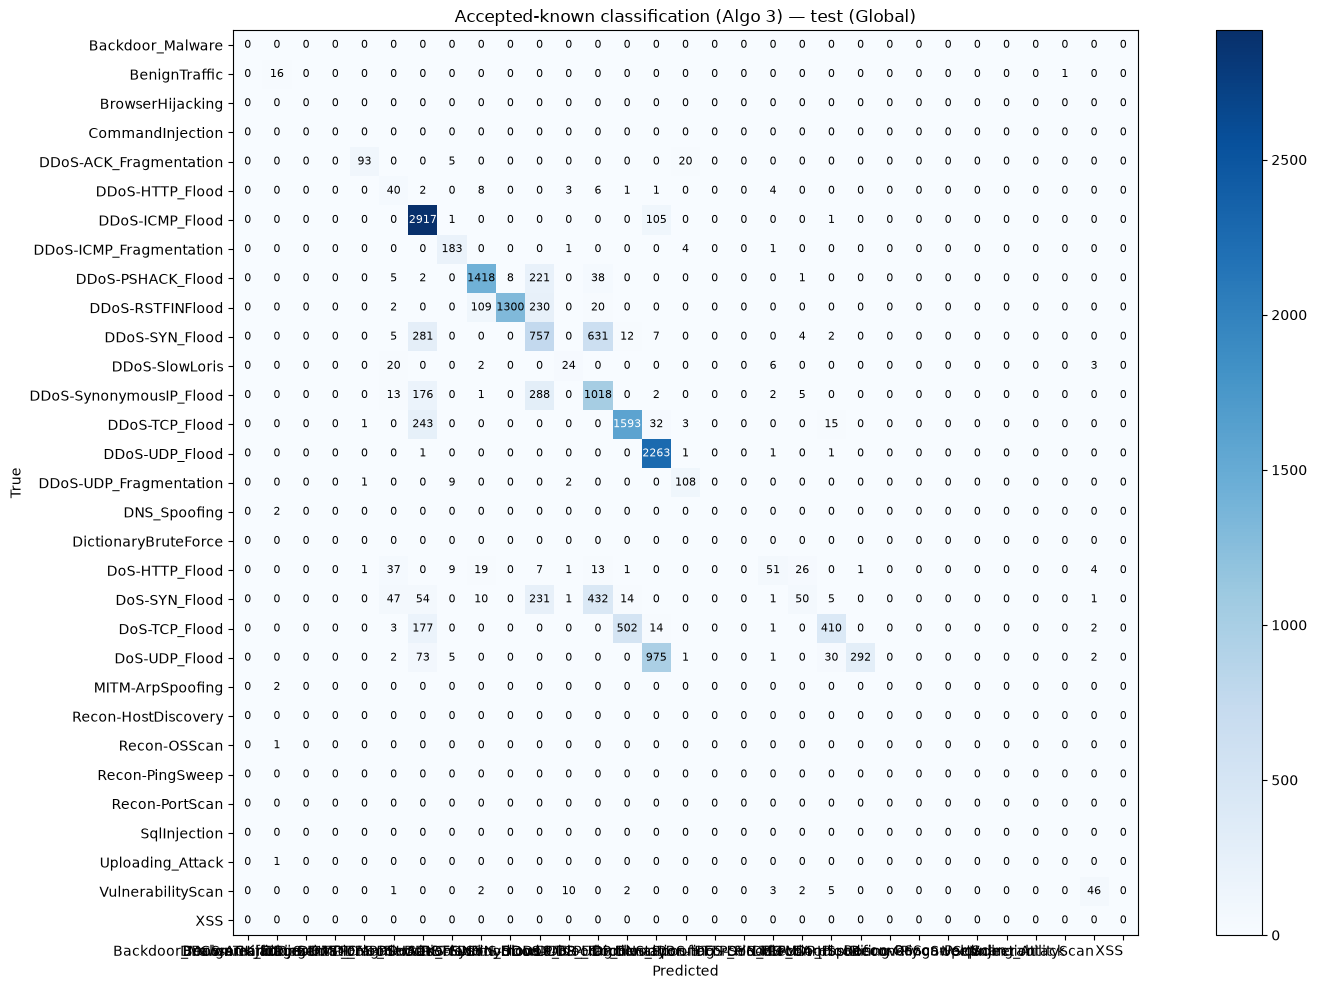

In [30]:
# Global test branch (must not be overwritten by train eval)
y_pred, radii, novelty_scores, f_maps = (
    labels_test_g,
    radii_test_g,
    scores_test_g,
    f_maps_test_g,
)
known_mask_test = y_pred != ZERO_DAY
test_eval_rej_rate = float(1.0 - known_mask_test.mean())
test_eval_acc = (
    float(np.mean(y_pred[known_mask_test] == y_test_np[known_mask_test]))
    if known_mask_test.any()
    else 0.0
)
test_eval_macro_f1 = float(
    f1_score(
        y_test_np[known_mask_test],
        y_pred[known_mask_test],
        average="macro",
        labels=label_ids,
        zero_division=0,
    )
)
test_eval_radius_mean = (
    float(radii[known_mask_test].mean()) if known_mask_test.any() else float("nan")
)

print(f"[test] mean certified radius (accepted): {test_eval_radius_mean:.4f}")
print(
    f"[test] reject rate (known): {test_eval_rej_rate:.4f} | acc (accepted): {test_eval_acc:.4f}"
)
assert abs(test_eval_rej_rate - FPR_g) < 1e-12

if known_mask_test.any():
    print("\n[test] classification report (accepted only):")
    print(
        classification_report(
            y_test_np[known_mask_test],
            y_pred[known_mask_test],
            labels=label_ids,
            target_names=class_names,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_test_np[known_mask_test], y_pred[known_mask_test], labels=label_ids
    )

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3) — test (Global)",
    )
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Class-Balanced Test Samples (Non-Rejected By $q$)


Running representative DPP coreset sampling (cap=30)...
Coreset selected: 789 samples (from full test n=18883).


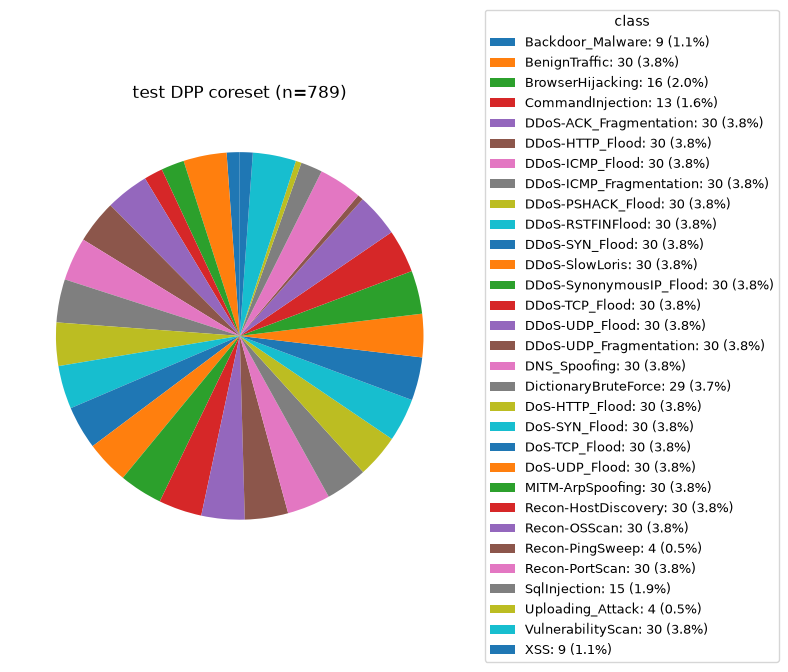

In [31]:
from scripts.data import greedy_dpp_sample

VAL_PER_CAP = 30
print(f"\nRunning representative DPP coreset sampling (cap={VAL_PER_CAP})...")

# coreset from FULL test pool (may differ from capped X_test when MORE_SUBSET=True)
X_test2, y_test2 = greedy_dpp_sample(
    X_test_full,
    y_test_full,
    per_class_cap=VAL_PER_CAP,
    seed=SEED,
)
print(
    f"Coreset selected: {X_test2.shape[0]} samples (from full test n={len(to_np_y(y_test_full))})."
)

# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_test2,
    class_names,
    title=f"test DPP coreset (n={len(to_np_y(y_test2))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

angles test: (789, 6), | USE_PCA=True
[test2   ] n=789


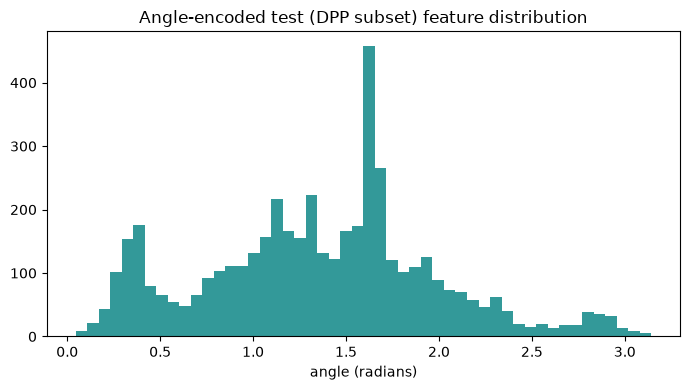

In [32]:
# raw -> scale -> optional pca -> [0, pi] using Day-23 train bounds
X_test_angles2 = to_angles(
    X_test2, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max
)

print(f"angles test: {X_test_angles2.shape}, | USE_PCA={USE_PCA}")

# cache DPP test subset (new angles -> one forward pass)
cache.compute(
    "test2",
    X_test_angles2,
    theta_star,
    forward_circuit,
    device=device,
    batch_size=batch_size,
    p=noise_rate,
    force=True,
)
print(f"[test2   ] n={cache.get('test2')['n']:,}")

fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))
ax1.hist(X_test_angles2.flatten(), bins=50, color="teal", alpha=0.8)
ax1.set_xlabel("angle (radians)")
ax1.set_title("Angle-encoded test (DPP subset) feature distribution")
plt.tight_layout()
plt.show()

In [33]:
y_pred2, radii2, novelty_scores2, f_maps2 = cached_qsnet_infer(
    cache.get("test2"),
    prototypes,
    q,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=zero_day,
    device=device,
    batch_size=batch_size,
)
y_test_np2 = to_np_y(y_test2).astype(int)
label_ids = list(range(num_classes))

[test_bal] mean certified radius (accepted): 0.0172
[test_bal] reject rate (known): 0.3853 | acc (accepted): 0.6103

[test_bal] classification report (accepted only):
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00         0
          BenignTraffic       0.33      1.00      0.50         1
       BrowserHijacking       0.00      0.00      0.00         0
       CommandInjection       0.00      0.00      0.00         0
 DDoS-ACK_Fragmentation       1.00      0.89      0.94        28
        DDoS-HTTP_Flood       0.49      0.61      0.54        28
        DDoS-ICMP_Flood       0.42      0.97      0.59        29
DDoS-ICMP_Fragmentation       0.77      0.93      0.84        29
      DDoS-PSHACK_Flood       0.68      0.77      0.72        30
       DDoS-RSTFINFlood       0.95      0.70      0.81        30
         DDoS-SYN_Flood       0.34      0.41      0.38        29
         DDoS-SlowLoris       0.75      0.50      0.

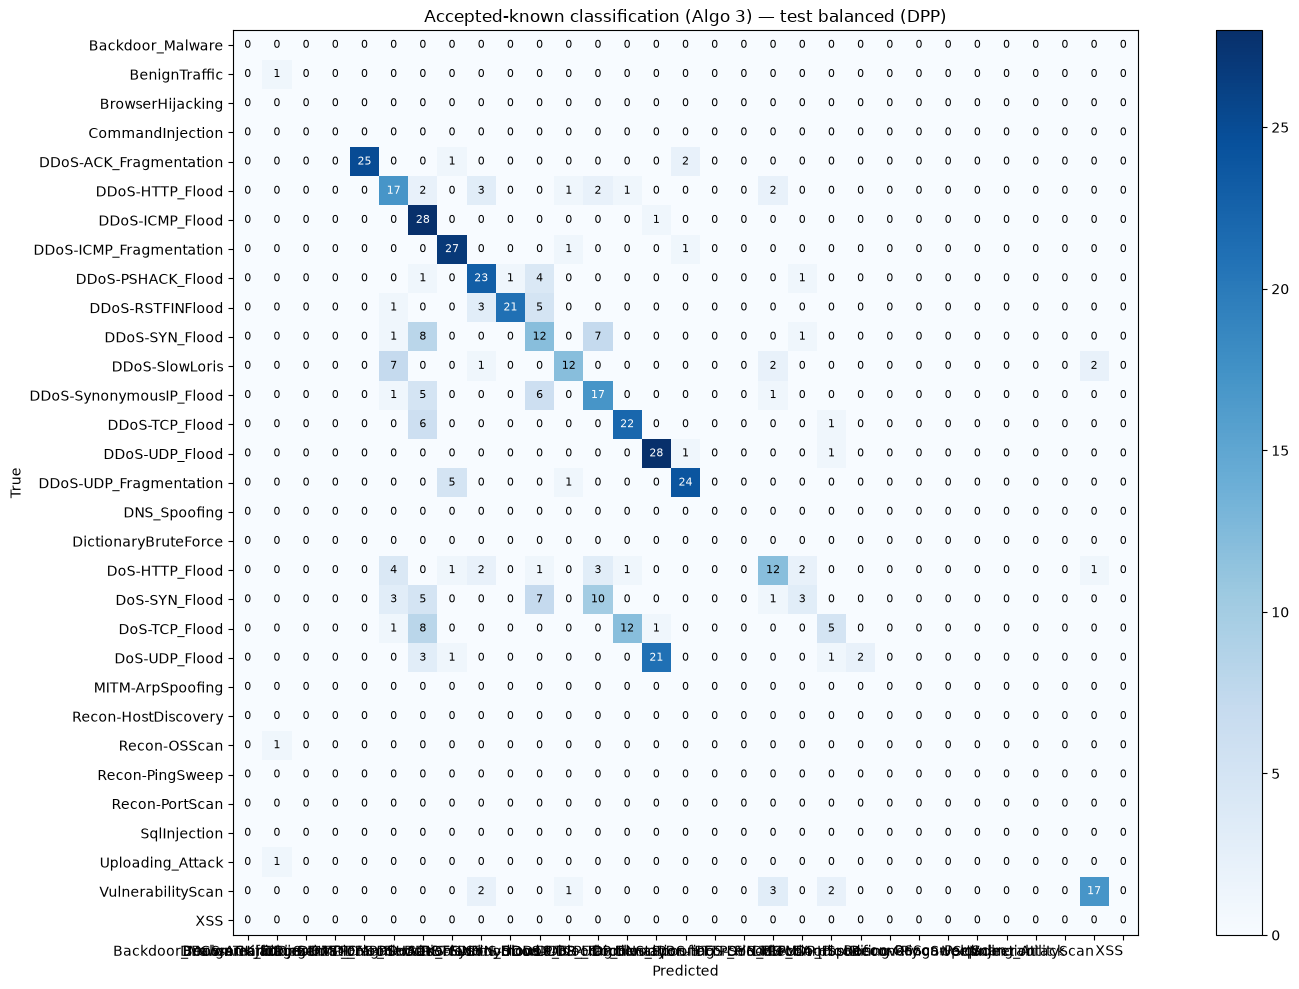

In [34]:
known_mask_test2 = y_pred2 != ZERO_DAY
test_bal_eval_rej_rate = float(1.0 - known_mask_test2.mean())
test_bal_eval_acc = (
    float(np.mean(y_pred2[known_mask_test2] == y_test_np2[known_mask_test2]))
    if known_mask_test2.any()
    else 0.0
)
test_bal_eval_macro_f1 = float(
    f1_score(
        y_test_np2[known_mask_test2],
        y_pred2[known_mask_test2],
        average="macro",
        labels=label_ids,
        zero_division=0,
    )
)
test_bal_eval_radius_mean = (
    float(radii2[known_mask_test2].mean()) if known_mask_test2.any() else float("nan")
)

print(f"[test_bal] mean certified radius (accepted): {test_bal_eval_radius_mean:.4f}")
print(
    f"[test_bal] reject rate (known): {test_bal_eval_rej_rate:.4f} | acc (accepted): {test_bal_eval_acc:.4f}"
)

if known_mask_test2.any():
    print("\n[test_bal] classification report (accepted only):")
    print(
        classification_report(
            y_test_np2[known_mask_test2],
            y_pred2[known_mask_test2],
            labels=label_ids,
            target_names=class_names,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y_test_np2[known_mask_test2], y_pred2[known_mask_test2], labels=label_ids
    )

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3) — test balanced (DPP)",
    )
    plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Full Test Samples (No Reject Mask)

[test CE] accuracy (full set, no reject mask): 0.7095
[test CE] macro-F1 (full set): 0.4070
[test CE] n=18883

[test CE] classification report (full set):
                         precision    recall  f1-score   support

       Backdoor_Malware       0.04      0.33      0.06         9
          BenignTraffic       0.64      0.33      0.44       458
       BrowserHijacking       0.00      0.00      0.00        16
       CommandInjection       0.02      0.08      0.03        13
 DDoS-ACK_Fragmentation       0.81      0.79      0.80       120
        DDoS-HTTP_Flood       0.12      0.51      0.19        70
        DDoS-ICMP_Flood       0.83      0.98      0.90      3025
DDoS-ICMP_Fragmentation       0.88      0.95      0.92       190
      DDoS-PSHACK_Flood       0.79      0.83      0.81      1712
       DDoS-RSTFINFlood       0.90      0.76      0.82      1688
         DDoS-SYN_Flood       0.59      0.93      0.72      1706
         DDoS-SlowLoris       0.27      0.35      0.30        62

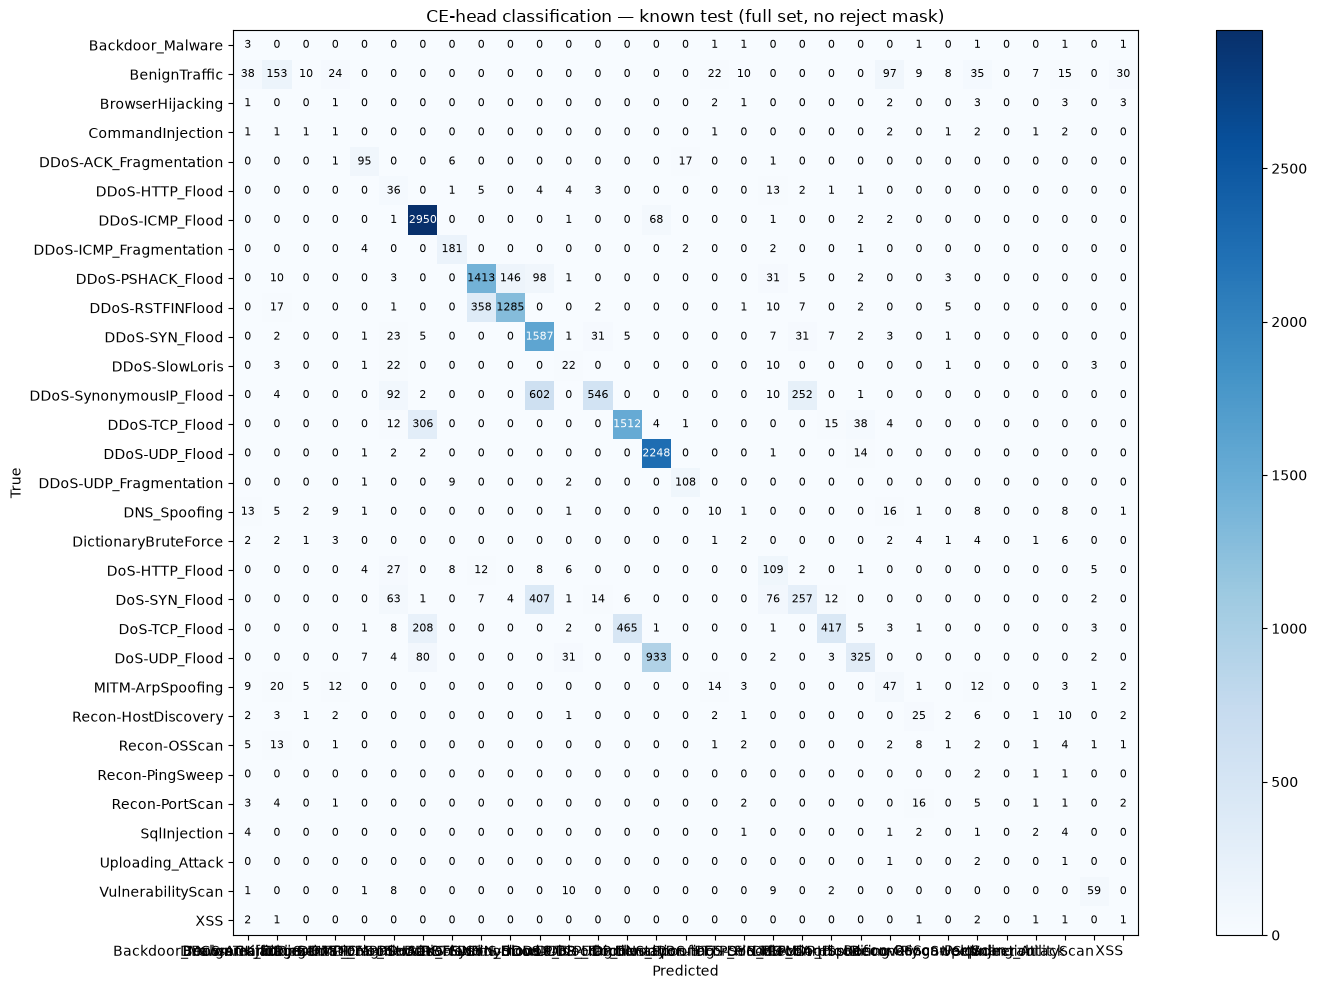

In [35]:
label_ids = list(range(num_classes))

# CE-head labels on full known test (no Algo-3 reject mask)
if head is None:
    raise RuntimeError(
        "Day-23 checkpoint has no head_state_dict — cannot run CE full-test CM"
    )

y_true_ce, y_pred_ce = cached_predict_labels(
    cache.get("test"),
    y_test,
    head,
    device=device,
    batch_size=batch_size,
)
test_ce_acc = float(accuracy_score(y_true_ce, y_pred_ce))
test_ce_macro_f1 = float(
    f1_score(y_true_ce, y_pred_ce, average="macro", labels=label_ids, zero_division=0)
)

print(f"[test CE] accuracy (full set, no reject mask): {test_ce_acc:.4f}")
print(f"[test CE] macro-F1 (full set): {test_ce_macro_f1:.4f}")
print(f"[test CE] n={len(y_true_ce)}")
print("\n[test CE] classification report (full set):")
print(
    classification_report(
        y_true_ce,
        y_pred_ce,
        labels=label_ids,
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true_ce, y_pred_ce, labels=label_ids)

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted",
    ylabel="True",
    title="CE-head classification — known test (full set, no reject mask)",
)
plt.setp(ax.get_xticklabels(), rotation=0, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=8,
        )
plt.tight_layout()
plt.show()

## Evaluation on Zero-Day Samples

Reuses Global zeroday branch (`labels_zday_g`). Detection rate under Global $q$ — not a multiclass CM.


In [36]:
df_zero_subset.head(3)

,duration,n_pkts_total,n_bytes_total,rate,pkt_size_min,pkt_size_max,pkt_size_mean,iat,protocol,conn_state,label_multiclass
0,10.740324,-0.250922,30.286178,1.125339,30.614619,26.768180,31.442014,2.210683,-0.909225,0.0,Mirai-udpplain
1,9.633689,-0.250922,30.121902,1.314613,28.996262,26.768180,31.325514,2.423348,-0.909225,0.0,Mirai-udpplain
2,0.000000,-0.250922,31.149634,-0.478757,31.491700,27.535064,32.361429,2.159752,0.000000,0.0,Mirai-greeth_flood


In [37]:
print(
    f"detected as ZERO_DAY: {(y_zero_pred == ZERO_DAY).sum()} / {len(y_zero_pred)} ({detection_rate:.1%})"
)
print(f"incorrectly accepted: {(y_zero_pred != ZERO_DAY).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

detected as ZERO_DAY: 115 / 10984 (1.0%)
incorrectly accepted: 10869
mean novelty score: 0.0600 | threshold q: 0.2260


## Logging

In [38]:
out_dir = Path("artifacts") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path) if ckpt_path else None,
    "cache_path": str(cache_path) if "cache_path" in dir() else None,
    "inference_mode": "ForwardCache + Global/Mondrian cached infer",
    "lphi_path": lphi_path,
    "L_phi_source": "analytic_lipschitz_bound (R/2)",
    "q_source": q_source,
    "q": float(q),
    "alpha": float(alpha),
    "L_phi": float(L_phi),
    "p": float(p),
    "C_f": float(Cf),
    "use_pca": bool(USE_PCA),
    "num_qubits": int(num_qubits),
    "num_layers": int(num_layers),
    # split-level evals (Global q on train / full test / DPP coreset)
    "train_eval_rej_rate": float(train_eval_rej_rate),
    "train_eval_acc": float(train_eval_acc),
    "train_eval_macro_f1": float(train_eval_macro_f1),
    "train_eval_radius_mean": float(train_eval_radius_mean),
    "test_eval_rej_rate": float(test_eval_rej_rate),
    "test_eval_acc": float(test_eval_acc),
    "test_eval_macro_f1": float(test_eval_macro_f1),
    "test_eval_radius_mean": float(test_eval_radius_mean),
    "test_ce_acc": float(test_ce_acc),
    "test_ce_macro_f1": float(test_ce_macro_f1),
    "n_test_ce": len(y_true_ce),
    "test_bal_eval_rej_rate": float(test_bal_eval_rej_rate),
    "test_bal_eval_acc": float(test_bal_eval_acc),
    "test_bal_eval_macro_f1": float(test_bal_eval_macro_f1),
    "test_bal_eval_radius_mean": float(test_bal_eval_radius_mean),
    "zeroday_detection_rate": float(detection_rate),
    "n_zeroday_eval": len(X_zero),
    "chosen_strategy": CHOSEN_STRATEGY,
    "strategies": strategies,
    "RQ1": {
        "chosen_strategy": CHOSEN_STRATEGY,
        "TPR_zeroday": float(TPR_zeroday),
        "FPR_known": float(FPR_known),
        "class_acc_known": float(class_acc_known),
        "alpha": float(alpha),
        "n_test": len(y_test_np),
        "n_zeroday": len(X_zero),
        "strategies": strategies,
    },
    "global_vs_mondrian": {
        "chosen_strategy": CHOSEN_STRATEGY,
        "df_far": df_far.to_dict(orient="records"),
        "df_comparison": df_global_vs_mondrian.to_dict(orient="records"),
        "strategies": strategies,
    },
}
torch.save(artifact, out_dir / f"{NOTEBOOK_NAME}.pt")
print("published:", (out_dir / f"{NOTEBOOK_NAME}.pt").resolve())
print(f"chosen_strategy={CHOSEN_STRATEGY}")
for name, m in strategies.items():
    print(
        f"  {name}: chosen={m['chosen_as_strategy']}  "
        f"TPR={m['TPR_zeroday']:.4f}  FPR={m['FPR_known']:.4f}  "
        f"acc={m['class_acc_known']:.4f}"
    )

write_history_log(
    history if history else {"radius_mean": [test_eval_radius_mean]},
    NOTEBOOK_NAME,
    extra=artifact,
    log_dir="logs",
)

published: /home/lawun330/Desktop/quantum-sentinel/artifacts/CICIoT2023/final-ciciot2023-algo3-cached (maqt).pt
chosen_strategy=global
  global: chosen=True  TPR=0.0105  FPR=0.0530  acc=0.7034
  mondrian: chosen=False  TPR=0.0442  FPR=0.1327  acc=0.7608


PosixPath('logs/final-ciciot2023-algo3-cached (maqt).log')